# Digits 数据集降维与可视化分析

## 实验目标
理解数据降维原理，掌握 **PCA** 与 **t-SNE** 算法应用，对比两者在手写数字数据集上的可视化效果。

| 算法 | 类型 | 特点 |
|------|------|------|
| PCA | 线性降维 | 方差最大化，可逆，快速 |
| t-SNE | 非线性降维 | 保持局部邻域结构，可视化效果好 |

## 数据集
**sklearn Digits 手写数字数据集**：
- 1797 个样本，每张 8×8 = 64 维特征
- 10 个类别（数字 0-9）
- 灰度图像，像素值 0-16

## 1. 导入库与数据加载

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
matplotlib.rcParams["axes.unicode_minus"] = False

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"数据集大小: {X.shape[0]} 样本 × {X.shape[1]} 特征")
print(f"类别数: {len(np.unique(y))}（数字 0~9）")
print(f"训练集: {X_train.shape[0]}  测试集: {X_test.shape[0]}")

数据集大小: 1797 样本 × 64 特征
类别数: 10（数字 0~9）
训练集: 1437  测试集: 360


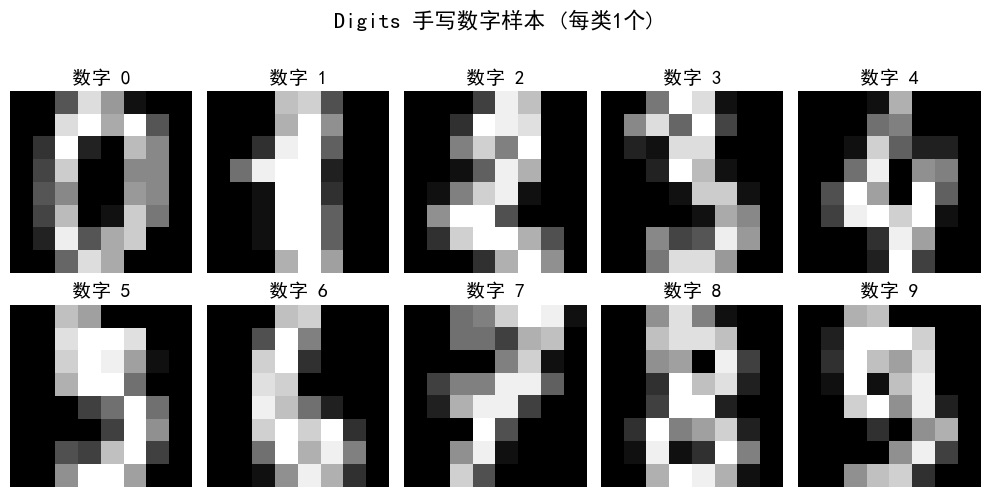

In [2]:
# 展示手写数字样本
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(digits.images[idx], cmap="gray")
    ax.set_title(f"数字 {i}", fontsize=14)
    ax.axis("off")
fig.suptitle("Digits 手写数字样本 (每类1个)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("digit_samples.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. PCA 降维实验

In [3]:
# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 先看全部主成分
pca_full = PCA().fit(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var)

# 降维到 2 维和 20 维
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_20 = PCA(n_components=20)
X_pca_20 = pca_20.fit_transform(X_scaled)

print("前2主成分解释方差比:", explained_var[:2].round(4))
print(f"前2主成分累计方差: {cumsum_var[1]*100:.2f}%")
print(f"前5主成分累计方差: {cumsum_var[4]*100:.2f}%")
print(f"前10主成分累计方差: {cumsum_var[9]*100:.2f}%")
print(f"前20主成分累计方差: {cumsum_var[19]*100:.2f}%")
print(f"前30主成分累计方差: {cumsum_var[29]*100:.2f}%")
print(f"降至20维可保留 {cumsum_var[19]*100:.1f}% 信息")

前2主成分解释方差比: [0.1203 0.0956]
前2主成分累计方差: 21.59%
前5主成分累计方差: 41.40%
前10主成分累计方差: 58.87%
前20主成分累计方差: 79.31%
前30主成分累计方差: 89.32%
降至20维可保留 79.3% 信息


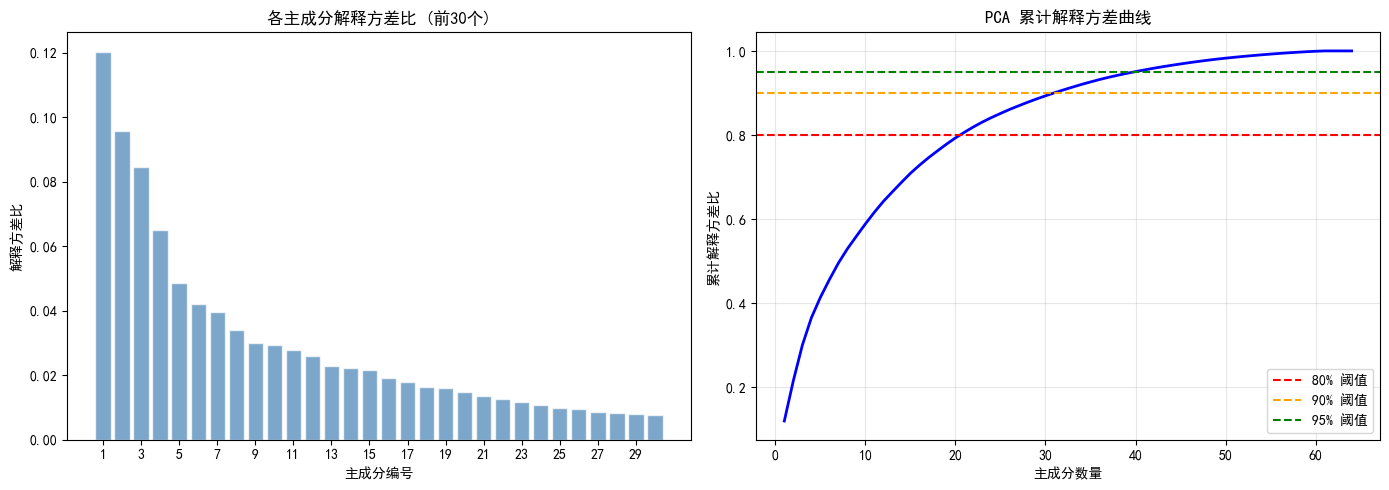

In [4]:
# 绘制累计解释方差曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 31), explained_var[:30], alpha=0.7, color="steelblue", edgecolor="white")
ax1.set_xlabel("主成分编号")
ax1.set_ylabel("解释方差比")
ax1.set_title("各主成分解释方差比 (前30个)")
ax1.set_xticks(range(1, 31, 2))

ax2.plot(range(1, 65), cumsum_var, "b-", linewidth=2)
ax2.axhline(y=0.8, color="r", linestyle="--", label="80% 阈值")
ax2.axhline(y=0.9, color="orange", linestyle="--", label="90% 阈值")
ax2.axhline(y=0.95, color="g", linestyle="--", label="95% 阈值")
ax2.set_xlabel("主成分数量")
ax2.set_ylabel("累计解释方差比")
ax2.set_title("PCA 累计解释方差曲线")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()

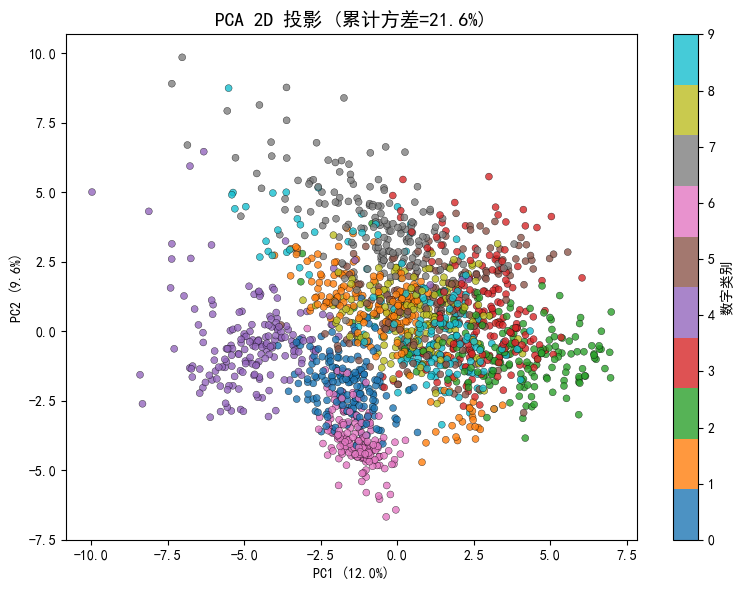

In [5]:
# PCA 2D 投影可视化
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap="tab10", s=25, alpha=0.8, edgecolors="k", linewidth=0.3)
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")
ax.set_title(f"PCA 2D 投影 (累计方差={cumsum_var[1]*100:.1f}%)", fontsize=14)
cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label("数字类别")
plt.tight_layout()
plt.show()

## 3. t-SNE 降维实验

In [7]:
# 不同随机种子对比
seeds = [0, 42, 123]
X_tsne_dict = {}

for s in seeds:
    tsne = TSNE(n_components=2, perplexity=30, random_state=s, n_iter_without_progress=1000, init="pca")
    X_tsne_dict[s] = tsne.fit_transform(X_scaled)
    print(f"seed={s:3d}  KL散度={tsne.kl_divergence_:.2f}")

seed=  0  KL散度=0.84
seed= 42  KL散度=0.84
seed=123  KL散度=0.84


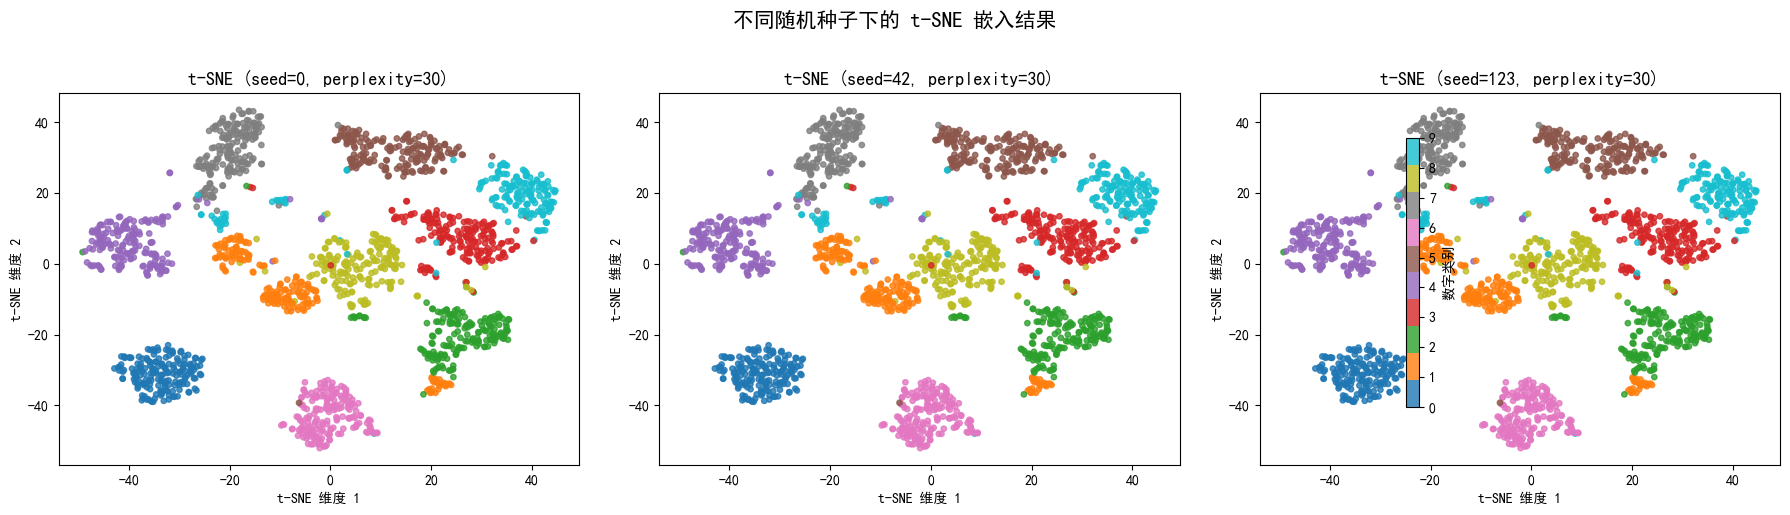

In [8]:
# 不同种子下的t-SNE可视化
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, s in enumerate(seeds):
    ax = axes[idx]
    sc = ax.scatter(X_tsne_dict[s][:, 0], X_tsne_dict[s][:, 1], c=y, cmap="tab10", s=15, alpha=0.8)
    ax.set_title(f"t-SNE (seed={s}, perplexity=30)", fontsize=13)
    ax.set_xlabel("t-SNE 维度 1")
    ax.set_ylabel("t-SNE 维度 2")
plt.colorbar(sc, ax=axes, ticks=range(10), label="数字类别", shrink=0.7)
plt.suptitle("不同随机种子下的 t-SNE 嵌入结果", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("tsne_seeds.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. PCA 与 t-SNE 对比分析

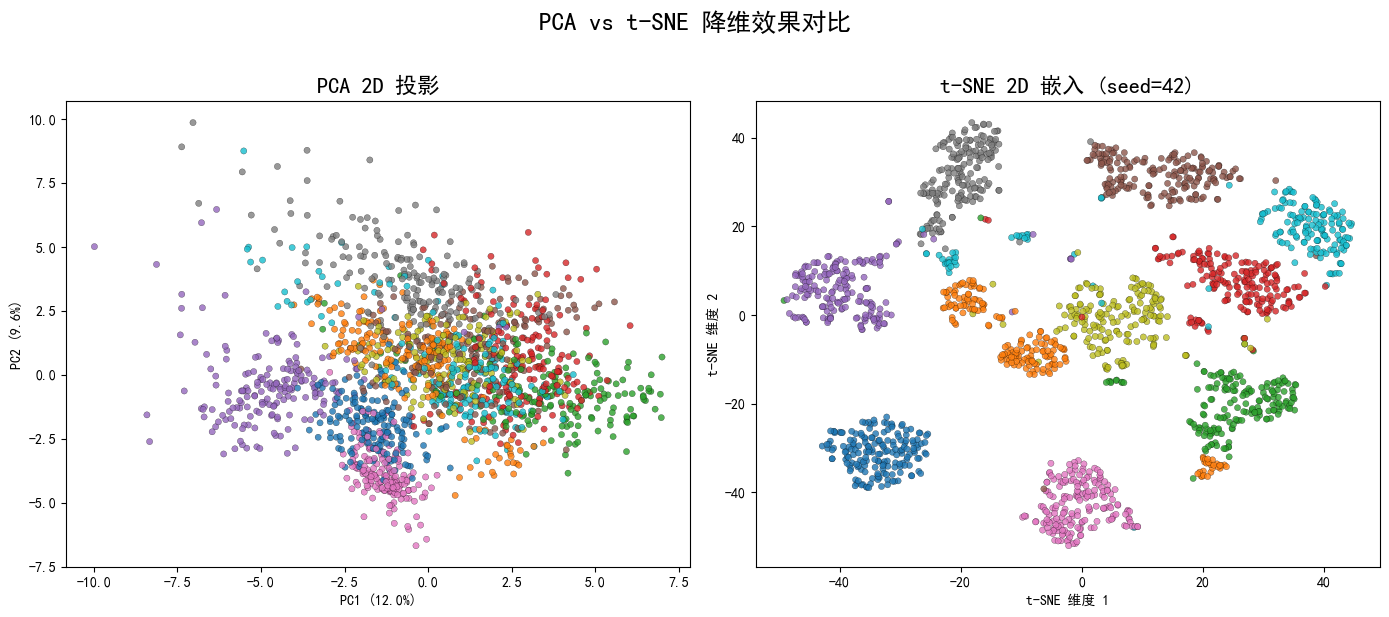

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.tab10

sc1 = axes[0].scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap=cmap, s=20, alpha=0.8, edgecolors="k", linewidth=0.2)
axes[0].set_title("PCA 2D 投影", fontsize=16, fontweight="bold")
axes[0].set_xlabel(f"PC1 ({explained_var[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({explained_var[1]*100:.1f}%)")

sc2 = axes[1].scatter(X_tsne_dict[42][:, 0], X_tsne_dict[42][:, 1], c=y, cmap=cmap, s=20, alpha=0.8, edgecolors="k", linewidth=0.2)
axes[1].set_title("t-SNE 2D 嵌入 (seed=42)", fontsize=16, fontweight="bold")
axes[1].set_xlabel("t-SNE 维度 1")
axes[1].set_ylabel("t-SNE 维度 2")
fig.suptitle("PCA vs t-SNE 降维效果对比", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("pca_vs_tsne.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
print("=" * 55)
print("         PCA vs t-SNE 对比分析")
print("=" * 55)
print()
print("【类别分离度对比】")
print("PCA  : 数字0/9混叠，1/7/8重叠严重，线性投影判别力不足")
print("t-SNE: 10个类别各自形成独立簇，边界清晰，仅簇间过渡略有交叉")
print()
print("【局部结构保持对比】")
print("PCA  : 保持全局最大方差，丢失局部邻域关系")
print("t-SNE: 通过概率分布匹配保留邻域结构，同类样本紧密聚合")
print()
print("【为何 t-SNE 可视化通常优于 PCA？】")
print("1. 非线性能力：t-SNE 能捕捉 PCA（线性）无法捕捉的非线性流形结构")
print("2. 目标函数：Symmetric SNE 对近距离点施加更大梯度，强力聚合同类")
print("3. 类别感知：PCA 仅最大化方差（与标签无关），t-SNE 隐式利用邻域标签")
print("4. perplexity 灵活性：可调整局部与全局平衡（推荐5~50）")
print()
print("【PCA 不可替代的优势】")
print("1. 确定性算法（无随机性），结果 100% 可复现")
print("2. 计算速度 O(min(n^2p, np^2))，远快于 t-SNE 的 O(n^2)")
print("3. 可逆（可重构原始数据），适合数据压缩/去噪预处理")
print("4. 解释方差比直观衡量信息保留量（降维有损可控）")
print()
print("【实验结论】")
print("可视化展示用 t-SNE，数据预处理/压缩用 PCA")
print("=" * 55)

         PCA vs t-SNE 对比分析

【类别分离度对比】
PCA  : 数字0/9混叠，1/7/8重叠严重，线性投影判别力不足
t-SNE: 10个类别各自形成独立簇，边界清晰，仅簇间过渡略有交叉

【局部结构保持对比】
PCA  : 保持全局最大方差，丢失局部邻域关系
t-SNE: 通过概率分布匹配保留邻域结构，同类样本紧密聚合

【为何 t-SNE 可视化通常优于 PCA？】
1. 非线性能力：t-SNE 能捕捉 PCA（线性）无法捕捉的非线性流形结构
2. 目标函数：Symmetric SNE 对近距离点施加更大梯度，强力聚合同类
3. 类别感知：PCA 仅最大化方差（与标签无关），t-SNE 隐式利用邻域标签
4. perplexity 灵活性：可调整局部与全局平衡（推荐5~50）

【PCA 不可替代的优势】
1. 确定性算法（无随机性），结果 100% 可复现
2. 计算速度 O(min(n^2p, np^2))，远快于 t-SNE 的 O(n^2)
3. 可逆（可重构原始数据），适合数据压缩/去噪预处理
4. 解释方差比直观衡量信息保留量（降维有损可控）

【实验结论】
可视化展示用 t-SNE，数据预处理/压缩用 PCA
